In [1]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Safe to run locally: it does nothing outside Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Tutorial 14. Jeffery's orbits of a rigid dumbbell

## Background

A rigid axisymmetric body suspended in simple shear flow
$\mathbf{u}=\dot\gamma\,y\,\hat{\mathbf{e}}_x$ rotates around the vorticity
axis $\hat{\mathbf{e}}_z$ along closed, periodic orbits, the classical
result of Jeffery (1922).  For a spheroid of aspect ratio
$r=a_\parallel/a_\perp$, Bretherton (1962) showed that the orientation
$\mathbf{p}=\mathcal{R}(t)\cdot\mathbf{E}_1$ of the symmetry axis obeys

$$\dot{\mathbf{p}}\;=\;\boldsymbol{\Omega}\times\mathbf{p}\;+\;
\beta\,\bigl[\mathbf{E}\!\cdot\!\mathbf{p}\,-\,(\mathbf{p}\!\cdot\!\mathbf{E}\!\cdot\!\mathbf{p})\,\mathbf{p}\bigr],$$

with $\boldsymbol{\Omega}=-\tfrac12\dot\gamma\,\hat{\mathbf{e}}_z$,
$\mathbf{E}_{xy}=\mathbf{E}_{yx}=\tfrac12\dot\gamma$, and Bretherton
parameter $\beta=(r^2-1)/(r^2+1)$.  In spherical coordinates
$\mathbf{p}=(\sin\theta\cos\varphi,\sin\theta\sin\varphi,\cos\theta)$ the
orbit admits the closed-form parametrisation

$$\tan\varphi(t)\;=\;-\tfrac{1}{c}\tan\!\bigl(\dot\gamma\,t/(c+1/c)+\varphi_*\bigr),\qquad
\tan^2\theta\,\bigl(\cos^2\varphi+c^2\sin^2\varphi\bigr)\;=\;K^2,$$

with $c=\sqrt{(1+\beta)/(1-\beta)}$, period $T=2\pi(c+1/c)/\dot\gamma$, and
orbit constant $K\in[0,\infty)$.  

Below we 
1. build a rigid two-bead dumbbell, 
2. extract $\beta$ directly from the library's mobility tensors, 
3. compare the simulated to the analytical $\varphi(t),\theta(t)$ along one trajectory, 
4. sweep 16 initial conditions to draw the full family of Jeffery orbits on $S^2$.

### Imports

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=3, linewidth=100, suppress=True, sign=" ")

# Every PDF is written under this folder by figstyle.save(...).
FIGDIR = "figures"

## 1. Defining the rigid dumbbell

Two identical spheres of radius $1$ are placed at $x=\pm 1.5$ in the body
frame.  With no degrees of freedom the body is perfectly rigid; the YAML
exposes `myradius0`, `myradius1`, `distance`, `offset` as design parameters
so that any of them can be swept later without rebuilding the assembly.

In [3]:
yaml_data = """
design_names:
  - myradius
  - distance
  - offset

defaults:
  myradius0: 1.
  myradius1: 1.
  distance: 1.

spheres:
  - radius: myradius0
    position: [offset - myradius0 - distance/2, 0, 0]
  - radius: myradius1
    position: [offset + myradius1 + distance/2, 0, 0]
"""

In [4]:
mybody = sm.SoftBody(yaml_data, verbose=False)
print(repr(mybody))

SPHERE ASSEMBLY
  2 spheres
  0 degrees of freedom
  4 design parameters
  0 input parameters

Default values
  degrees of freedom dof: [] = []
  design parameters param: ['distance', 'myradius0', 'myradius1', 'offset'] = [ 1.  1.  1.  0.]
  input parameters param: []

SPHERE 0
  radius: 1.0
  position: [-1.5  0.   0. ]
  orientation: [ 0.  0.  0.]
  C_H:
[]
  C_K:
[]

SPHERE 1
  radius: 1.0
  position: [ 1.5  0.   0. ]
  orientation: [ 0.  0.  0.]
  C_H:
[]
  C_K:
[]



## 2. Body geometry

A first sanity figure: the two spheres in their body frame, with the body
axes $\mathbf{E}_1,\mathbf{E}_2,\mathbf{E}_3$ drawn from the origin.  The
long (symmetry) axis is $\mathbf{E}_1$; $\mathbf{E}_2$ and $\mathbf{E}_3$
span the equatorial plane.  Saved as `figures/fig_dumbbell_geometry.pdf`.

PosixPath('figures/fig_dumbbell_geometry.pdf')

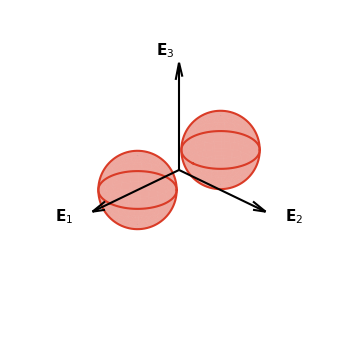

In [17]:
fig_geom, ax_geom = figstyle.figure_3d(size="half", aspect=1.0)

# Body-frame bead positions and radii from the YAML defaults.
RADII = np.array([1.0, 1.0])
POSITIONS_BODY = np.array([[-1.5, 0.0, 0.0], [1.5, 0.0, 0.0]])

axis_length = float(np.max(np.abs(POSITIONS_BODY)) + RADII.max() + 0.)
figstyle.add_body_axes(ax_geom, length=1.25 * axis_length, show_labels=True)

for centre, radius in zip(POSITIONS_BODY, RADII, strict=True):
    figstyle.add_sphere(ax_geom, centre, radius)

bbox = axis_length * 1.
ax_geom.set_xlim(-bbox, bbox)
ax_geom.set_ylim(-bbox, bbox)
ax_geom.set_zlim(-bbox, bbox)

figstyle.displace_label(ax_geom, "axis_label_E1", text=r"$\mathbf{E}_1$" , offset=(0.3* axis_length, 0, 0.))
figstyle.displace_label(ax_geom, "axis_label_E2", text=r"$\mathbf{E}_2$" , offset=(0, 0.3* axis_length, 0.))
figstyle.displace_label(ax_geom, "axis_label_E3", text=r"$\mathbf{E}_3$" , offset=(0.2* axis_length, 0, 0.))

figstyle.save(fig_geom, "fig_dumbbell_geometry", figdir=FIGDIR)


## 3. Shear flow and the Bretherton parameter

We use a simple shear $\mathbf{u}=\dot\gamma\,y\,\hat{\mathbf{e}}_x$
with $\dot\gamma=1$.  Its vorticity is
$\boldsymbol{\Omega}=-\tfrac12\hat{\mathbf{e}}_z$ and its rate of strain
has only the off-diagonal $E_{xy}=E_{yx}=\tfrac12$ component.

In [6]:
SHEAR_RATE = 1.0
shear_flow = sm.shear_flow(shear_rate=SHEAR_RATE)

pos = [1.0, 2.0, 3.0]
grad_u = shear_flow.gradient(pos)
Omega, rate_of_strain = shear_flow.omega_rate_of_strain(pos)
print("Velocity gradient \u2207u:\n", grad_u)
print("Vorticity \u03A9:", Omega)
print("Rate of strain E:\n", rate_of_strain)

Velocity gradient ∇u:
 [[ 0.  1.  0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]
Vorticity Ω: [ 0.   0.  -0.5]
Rate of strain E:
 [[ 0.   0.5  0. ]
 [ 0.5  0.   0. ]
 [ 0.   0.   0. ]]


The Bretherton parameter $\beta$ for the dumbbell is read directly from
the body's strain-coupling tensor `C_E`: the entry
`C_E[-1, 1]` is the coupling between the body-frame angular velocity
component along $\mathbf{E}_3$ (the vorticity-aligned axis when
$\mathbf{p}=\mathbf{E}_1$) and the $E_{xy}$ component of the imposed
strain.  Numerically $\beta\approx 0.717$, intermediate between the sphere
limit $\beta=0$ and the infinitely slender rod $\beta=1$.

In [7]:
tensors = mybody.compute_tensors()
Bretherton = float(tensors.C_E[-1, 1])
c = np.sqrt((1.0 + Bretherton) / (1.0 - Bretherton))
period = 2.0 * np.pi * (c + 1.0 / c) / SHEAR_RATE
print(f"Bretherton parameter  \u03B2 = {Bretherton:.4f}")
print(f"Aspect ratio          c = sqrt((1+\u03B2)/(1-\u03B2)) = {c:.4f}")
print(f"Jeffery period        T = 2\u03C0 (c + 1/c)/\u03B3\u0307 = {period:.4f}")

Bretherton parameter  β = 0.7169
Aspect ratio          c = sqrt((1+β)/(1-β)) = 2.4625
Jeffery period        T = 2π (c + 1/c)/γ̇ = 18.0238


## 4. Single trajectory: $\varphi(t),\,\theta(t)$

We run one rollout with an initial Rodrigues vector that tilts the long
axis out of the flow plane, then extract the spherical angles of
$\mathbf{p}(t)=\mathcal{R}(t)\cdot\mathbf{E}_1$ and compare to the closed-form
solution.

In [8]:
def p_to_rod(p):
    """Rodrigues vector that brings body-frame E_1 onto lab vector p."""
    e1 = np.array([1.0, 0.0, 0.0])
    p = np.asarray(p, dtype=float)
    p = p / np.linalg.norm(p)
    cos_a = float(np.clip(p @ e1, -1.0, 1.0))
    angle = float(np.arccos(cos_a))
    axis = np.cross(e1, p)
    norm = float(np.linalg.norm(axis))
    if norm > 1e-10:
        return angle * axis / norm
    return np.zeros(3) if angle < 0.1 else angle * np.array([0.0, 1.0, 0.0])


def phi_theta_of_p(p):
    """Spherical angles (φ, θ) of a unit vector p with θ measured from +ẑ."""
    p = np.asarray(p)
    phi = np.arctan2(p[..., 1], p[..., 0])
    theta = np.arccos(np.clip(p[..., 2], -1.0, 1.0))
    return phi, theta


def jeffery_phi_theta(beta, phi0, theta0, t, shear_rate=1.0):
    """Closed-form Jeffery orbit for the long-axis spherical angles.

    Orbit invariant: tan²θ (cos²φ + c² sin²φ) = K²,
    with c = sqrt((1+β)/(1-β)). Returns θ ∈ [0, π/2]; pair with
    the antipode flip below for ICs in the lower hemisphere.
    """
    c = np.sqrt((1.0 + beta) / (1.0 - beta))
    tau0 = np.arctan2(-c * np.sin(phi0), np.cos(phi0))
    tau = shear_rate * np.asarray(t) / (c + 1.0 / c) + tau0
    phi = np.arctan2(-np.sin(tau) / c, np.cos(tau))
    K = np.tan(theta0) * np.sqrt(np.cos(phi0) ** 2 + c ** 2 * np.sin(phi0) ** 2)
    theta = np.arctan2(K, np.sqrt(np.cos(phi) ** 2 + c ** 2 * np.sin(phi) ** 2))
    return phi, theta

In [9]:
# Tilt the long axis 0.6 rad around -y_hat \u21d2 p_0 in the upper hemisphere.
init_orientation = jnp.array([0.0, -0.6, 0.0])

dt = 0.02
n_periods = 2
final_time = n_periods * period
n_steps = int(final_time / dt)
t = jnp.linspace(dt, final_time, n_steps)

rollout = sm.FlowBodyRollout(soft_body=mybody, flow=shear_flow)
positions, orientations, _ = rollout.rollout(
    dt=dt, n_steps=n_steps, init_orientation=init_orientation,
)


@jax.jit
def p_from_rod(rod):
    return sm.rotation_matrix(rod) @ jnp.array([1.0, 0.0, 0.0])


p_num = np.array(jax.vmap(p_from_rod)(orientations))
phi_num, theta_num = phi_theta_of_p(p_num)
phi_num = np.unwrap(phi_num)

phi0, theta0 = phi_theta_of_p(np.array(p_from_rod(init_orientation)))
phi_ana, theta_ana = jeffery_phi_theta(Bretherton, phi0, theta0, np.array(t), SHEAR_RATE)
phi_ana = np.unwrap(phi_ana)

err_phi = float(np.max(np.abs((phi_num - phi_ana + np.pi) % (2 * np.pi) - np.pi)))
err_theta = float(np.max(np.abs(theta_num - theta_ana)))
print(f"max |\u03C6_num \u2212 \u03C6_ana|  = {err_phi:.2e}")
print(f"max |\u03B8_num \u2212 \u03B8_ana|  = {err_theta:.2e}")

max |φ_num − φ_ana|  = 5.69e-03
max |θ_num − θ_ana|  = 1.20e-03


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


PosixPath('figures/fig_jeffery_angles.pdf')

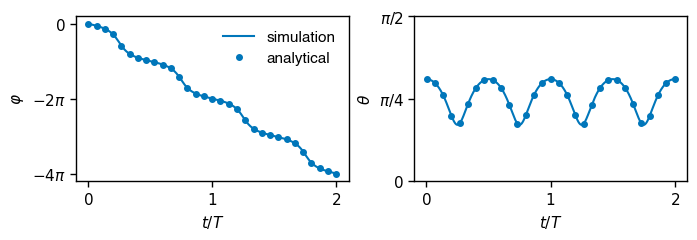

In [10]:
fig_ang, axes_ang = figstyle.subplots(size="full", aspect=658 / 220, ncols=2)
stride = max(1, len(t) // 30)
t_np = np.array(t)

axes_ang[0].plot(
    t_np / period, phi_num,
    color=figstyle.COLORS["blue"], linewidth=1.5, label="simulation",
)
axes_ang[0].plot(
    t_np[::stride] / period, phi_ana[::stride],
    color=figstyle.COLORS["blue"], marker="o", linestyle="none",
    markersize=4, label="analytical",
)
axes_ang[0].set_xlabel("$t / T$")
axes_ang[0].set_xticks(
    [0, 1, 2],
    [r"$0$", r"$1$", r"$2$"],
)
axes_ang[0].set_ylabel(r"$\varphi$")
axes_ang[0].set_yticks(
    [-4 * np.pi, -2 * np.pi, 0],
    [r"$-4\pi$", r"$-2\pi$", "$0$"],
)
axes_ang[0].legend(loc="upper right", frameon=False)

axes_ang[1].plot(
    t_np / period, theta_num,
    color=figstyle.COLORS["blue"], linewidth=1.5, label="rollout",
)
axes_ang[1].plot(
    t_np[::stride] / period, theta_ana[::stride],
    color=figstyle.COLORS["blue"], marker="o", linestyle="none",
    markersize=4, label="analytical",
)
axes_ang[1].set_xlabel("$t / T$")
axes_ang[1].set_xticks(
    [0, 1, 2],
    [r"$0$", r"$1$", r"$2$"],
)
axes_ang[1].set_ylabel(r"$\theta$")
axes_ang[1].set_yticks(
    [0, np.pi / 4, np.pi / 2,],
    ["$0$", r"$\pi/4$", r"$\pi/2$", ],
)

figstyle.save(fig_ang, "fig_jeffery_angles", figdir=FIGDIR)

## 5. Orbit family on $S^2$

Sweeping $N_\mathrm{traj}=16$ Fibonacci-distributed initial directions
$\mathbf{p}_0\in S^2$ shows the full family of Jeffery orbits: closed
curves that encircle the vorticity axis $\hat{\mathbf{e}}_z$, with the
orbit constant $K$ varying smoothly across the sphere.  Every rollout
trajectory is overlaid with sub-sampled markers from the analytical
solution; the dumbbell is drawn translucently at half scale inside the
unit sphere.

In [11]:
N_TRAJ = 16
golden = np.pi * (3 - np.sqrt(5))
idx = np.arange(N_TRAJ)
z_fib = 1 - (2 * idx + 1) / N_TRAJ
r_fib = np.sqrt(np.maximum(1 - z_fib ** 2, 0))
init_ps = np.column_stack([
    r_fib * np.cos(golden * idx),
    r_fib * np.sin(golden * idx),
    z_fib,
])
init_rods = np.array([p_to_rod(p) for p in init_ps])

N_STEPS_orbit = 2000
DT_orbit = 1.05 * period / N_STEPS_orbit


@jax.jit
def run_one(rod0):
    _, oris_one, _ = rollout.rollout(DT_orbit, N_STEPS_orbit, init_orientation=rod0)
    return oris_one


oris_all = np.array(jax.vmap(run_one)(jnp.asarray(init_rods)))


@jax.jit
def ps_from_rods(rods):
    return jax.vmap(p_from_rod)(rods)


p_orbit_lib = np.array(jax.vmap(ps_from_rods)(oris_all))  # (N_TRAJ, N_STEPS, 3)

# Analytical orbit per IC, sampled at the same post-step times as the rollout.
t_orbit = (np.arange(N_STEPS_orbit) + 1) * DT_orbit
p_orbit_ana = np.zeros_like(p_orbit_lib)
for i, p0 in enumerate(init_ps):
    sign = 1.0 if p0[2] >= 0 else -1.0
    p0u = sign * p0
    phi0_i, theta0_i = phi_theta_of_p(p0u)
    if theta0_i < 1e-6:
        p_orbit_ana[i] = p0  # vorticity-axis fixed point
        continue
    phi_i, theta_i = jeffery_phi_theta(Bretherton, phi0_i, theta0_i, t_orbit, SHEAR_RATE)
    p_orbit_ana[i] = sign * np.column_stack([
        np.sin(theta_i) * np.cos(phi_i),
        np.sin(theta_i) * np.sin(phi_i),
        np.cos(theta_i),
    ])

err = np.max(np.linalg.norm(p_orbit_lib - p_orbit_ana, axis=-1))
print(f"orbit family: {N_TRAJ} ICs, max |p_num − p_ana| = {err:.2e}")

orbit family: 16 ICs, max |p_num − p_ana| = 1.25e-10


PosixPath('figures/fig_jeffery_s2_orbits.pdf')

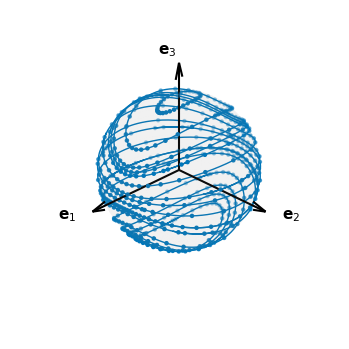

In [16]:
fig_orb, ax_orb = figstyle.figure_3d(size="half", aspect=1.0)


# (E1, E2, E3) body axes for reference.
figstyle.add_body_axes(ax_orb, length=1.5, show_labels=True)
figstyle.displace_label(ax_orb, "axis_label_E1", text=r"$\mathbf{e}_1$", offset=(0.3, 0, 0.))
figstyle.displace_label(ax_orb, "axis_label_E2", text=r"$\mathbf{e}_2$", offset=(0, 0.3, 0.))
figstyle.displace_label(ax_orb, "axis_label_E3", text=r"$\mathbf{e}_3$", offset=(0.2, 0, 0.))

# Translucent unit sphere.
u_s, v_s = np.mgrid[0:2 * np.pi:60j, 0:np.pi:30j]
ax_orb.plot_surface(
    0.998 * np.cos(u_s) * np.sin(v_s),
    0.998 * np.sin(u_s) * np.sin(v_s),
    0.998 * np.cos(v_s),
    color=figstyle.COLORS["grey"], alpha=0.05,
    linewidth=0, antialiased=True, shade=False,
)

# Dumbbell drawn at half scale inside the sphere as a visual reference.
# for centre, radius in zip(POSITIONS_BODY, RADII, strict=True):
#     figstyle.add_sphere(ax_orb, 0.25 * centre, 0.25 * radius,
#                         alpha=0.10, contour_width=1.0)

ana_stride = max(1, N_STEPS_orbit // 32)
for i in range(N_TRAJ):
    ax_orb.plot(
        p_orbit_lib[i, :, 0], p_orbit_lib[i, :, 1], p_orbit_lib[i, :, 2],
        color=figstyle.COLORS["blue"], linewidth=1.0,
        label="rollout (RK4)" if i == 0 else None,
    )
    ax_orb.scatter(
        p_orbit_ana[i, ::ana_stride, 0],
        p_orbit_ana[i, ::ana_stride, 1],
        p_orbit_ana[i, ::ana_stride, 2],
        color=figstyle.COLORS["blue"], s=5,
        label="analytical" if i == 0 else None,
    )

ax_orb.set_xlim(-1.2, 1.2)
ax_orb.set_ylim(-1.2, 1.2)
ax_orb.set_zlim(-1.2, 1.2)

figstyle.save(fig_orb, "fig_jeffery_s2_orbits", figdir=FIGDIR)

## Summary

The rigid two-bead dumbbell in `softmobility` reproduces Jeffery's classical
orbits to within RK4 truncation error.  The Bretherton parameter
$\beta\approx 0.717$ is extracted directly from the library's
strain-coupling tensor `C_E[-1,1]`, and the resulting closed-form
$\varphi(t),\theta(t)$ match the rollout in both the single-trajectory
panel and across all 16 Fibonacci initial conditions.  The same machinery
extends without modification to non-spheroidal axisymmetric bodies, where
$\beta$ is no longer given by the spheroidal aspect-ratio formula but is
still computed from the body's mobility tensors.

## References

F. P. Bretherton, The motion of rigid particles in a shear flow at low
Reynolds number, *J. Fluid Mech.* **14**, 284 (1962).

K. Ishimoto, Jeffery’s orbits and microswimmers in flows: A theoretical review, *J. Phys. Soc. Japan* **92**, 062001 (2023).

G. B. Jeffery, The motion of ellipsoidal particles immersed in a viscous
fluid, *Proc. Roy. Soc. A* **102**, 161 (1922).

S. Kim and S. J. Karrila, *Microhydrodynamics: principles and selected
applications*, Butterworth-Heinemann (2013), ch. 3.

L. G. Leal, *Advanced Transport Phenomena: Fluid Mechanics and Convective
Transport Processes*, Cambridge University Press (2007), ch. 7.